In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2
import os
import random
from pathlib import Path
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("ExDark_split/train", transform=transform)
val_dataset   = datasets.ImageFolder("ExDark_split/val",   transform=transform)
test_dataset  = datasets.ImageFolder("ExDark_split/test",  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))
print("Classes:", class_names)

Train: 5886
Val:   729
Test:  748
Classes: ['Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat', 'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table']


In [3]:
def build_model(num_classes, device):
    """Build ResNet18 with fine-tuned classification head."""
    model = models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def train_model(model, train_loader, epochs=10):
    """Fine-tune model and return per-epoch training accuracies."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    train_accs = []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
        train_acc = correct / total
        train_accs.append(train_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss={running_loss:.4f} | Train Acc={train_acc:.4f}")
    return train_accs

def evaluate_model(model, loader):
    """Evaluate model on a given dataloader, return accuracy."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return correct / total

In [4]:
EPOCHS = 10

# Train baseline model on original ExDark
model_baseline = build_model(num_classes=len(class_names), device=device)
baseline_train_accs = train_model(model_baseline, train_loader, epochs=EPOCHS)

Epoch 1/10 | Loss=238.8535 | Train Acc=0.5669
Epoch 2/10 | Loss=99.5893 | Train Acc=0.8349
Epoch 3/10 | Loss=35.2161 | Train Acc=0.9589
Epoch 4/10 | Loss=13.1977 | Train Acc=0.9915
Epoch 5/10 | Loss=6.0474 | Train Acc=0.9963
Epoch 6/10 | Loss=3.8179 | Train Acc=0.9971
Epoch 7/10 | Loss=2.3489 | Train Acc=0.9973
Epoch 8/10 | Loss=2.2170 | Train Acc=0.9971
Epoch 9/10 | Loss=1.8834 | Train Acc=0.9971
Epoch 10/10 | Loss=1.6673 | Train Acc=0.9971


In [5]:
baseline_acc = evaluate_model(model_baseline, test_loader)

print("=" * 50)
print(f"Baseline Test Accuracy (Original ExDark): {baseline_acc*100:.2f}%")
print("=" * 50)

Baseline Test Accuracy (Original ExDark): 70.19%


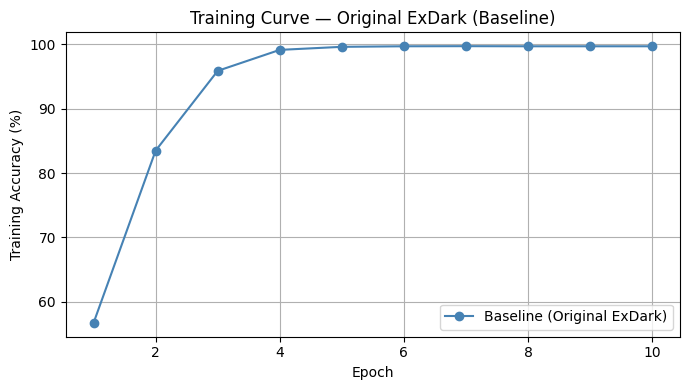

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), [a*100 for a in baseline_train_accs],
         marker='o', color='steelblue', label='Baseline (Original ExDark)')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Curve — Original ExDark (Baseline)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("baseline_training_curve.png", dpi=150)
plt.show()

In [7]:
src_root = "ExDark_split"
dst_root = "ExDark_CLAHE"

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for split in ["train", "val", "test"]:
    split_path = os.path.join(src_root, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        target_cls = os.path.join(dst_root, split, cls)
        Path(target_cls).mkdir(parents=True, exist_ok=True)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            l = clahe.apply(l)
            enhanced = cv2.merge((l, a, b))
            enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
            cv2.imwrite(os.path.join(target_cls, img_name), enhanced)

print("CLAHE dataset created!")

CLAHE dataset created!


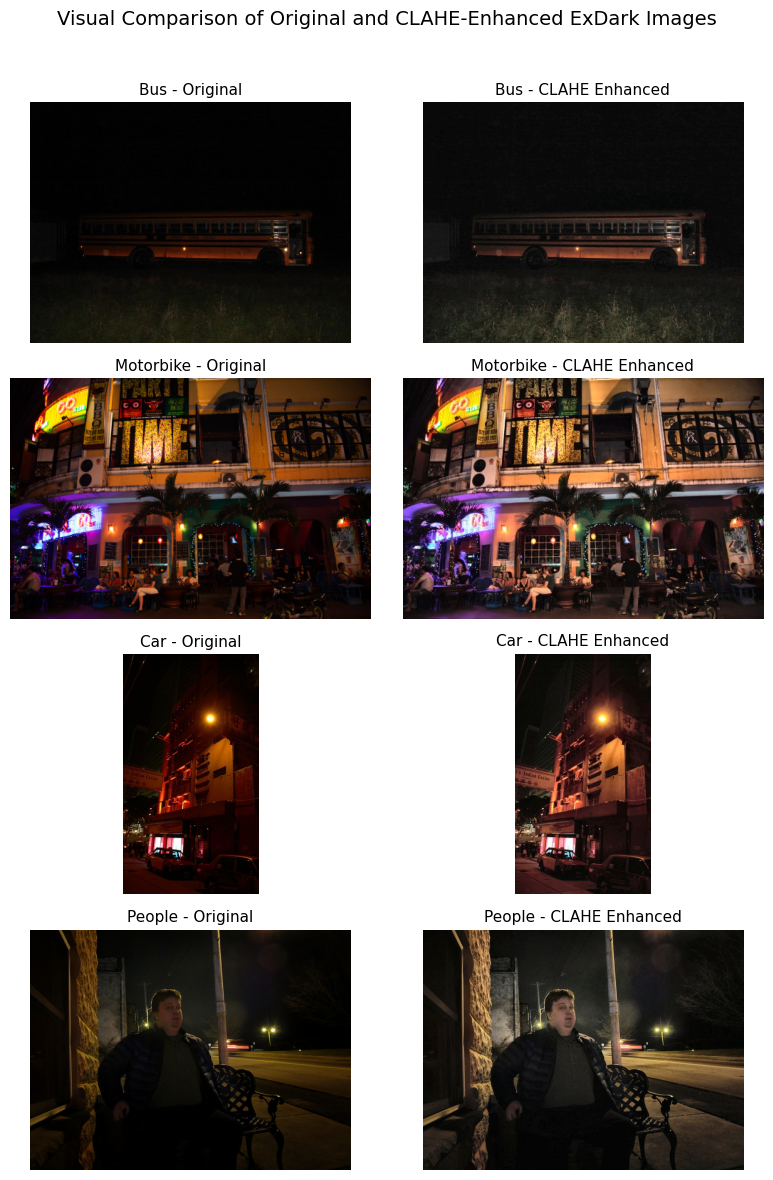

In [10]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)

selected_classes = ["Bus", "Motorbike", "Car", "People"]  # 换成你数据集中真实存在的类别
valid_classes = [cls for cls in selected_classes if cls in class_names]

fig, axes = plt.subplots(len(valid_classes), 2, figsize=(8, 3 * len(valid_classes)))

if len(valid_classes) == 1:
    axes = [axes]

for row, cls in enumerate(valid_classes):
    orig_dir = os.path.join("ExDark_split", "test", cls)
    clahe_dir = os.path.join("ExDark_CLAHE", "test", cls)

    files = [
        f for f in os.listdir(orig_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
        and os.path.exists(os.path.join(clahe_dir, f))
    ]

    img_name = random.choice(files)

    orig_img = Image.open(os.path.join(orig_dir, img_name)).convert("RGB")
    clahe_img = Image.open(os.path.join(clahe_dir, img_name)).convert("RGB")

    axes[row][0].imshow(orig_img)
    axes[row][0].set_title(f"{cls} - Original", fontsize=11)
    axes[row][0].axis("off")

    axes[row][1].imshow(clahe_img)
    axes[row][1].set_title(f"{cls} - CLAHE Enhanced", fontsize=11)
    axes[row][1].axis("off")

plt.suptitle("Visual Comparison of Original and CLAHE-Enhanced ExDark Images", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("clahe_visual_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Load CLAHE dataset
clahe_train = datasets.ImageFolder("ExDark_CLAHE/train", transform=transform)
clahe_val   = datasets.ImageFolder("ExDark_CLAHE/val",   transform=transform)
clahe_test  = datasets.ImageFolder("ExDark_CLAHE/test",  transform=transform)

clahe_train_loader = DataLoader(clahe_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
clahe_val_loader   = DataLoader(clahe_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
clahe_test_loader  = DataLoader(clahe_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("CLAHE Train:", len(clahe_train))
print("CLAHE Val:  ", len(clahe_val))
print("CLAHE Test: ", len(clahe_test))

CLAHE Train: 5886
CLAHE Val:   729
CLAHE Test:  748


In [13]:
# Train model on CLAHE-enhanced dataset
model_clahe = build_model(num_classes=len(class_names), device=device)
clahe_train_accs = train_model(model_clahe, clahe_train_loader, epochs=EPOCHS)

Epoch 1/10 | Loss=229.8607 | Train Acc=0.5899
Epoch 2/10 | Loss=96.0670 | Train Acc=0.8420
Epoch 3/10 | Loss=30.9088 | Train Acc=0.9638
Epoch 4/10 | Loss=10.3876 | Train Acc=0.9935
Epoch 5/10 | Loss=6.0020 | Train Acc=0.9964
Epoch 6/10 | Loss=3.8826 | Train Acc=0.9968
Epoch 7/10 | Loss=2.6205 | Train Acc=0.9975
Epoch 8/10 | Loss=2.1047 | Train Acc=0.9978
Epoch 9/10 | Loss=1.6774 | Train Acc=0.9969
Epoch 10/10 | Loss=1.8345 | Train Acc=0.9975


In [14]:
clahe_acc = evaluate_model(model_clahe, clahe_test_loader)

print("=" * 50)
print(f"CLAHE Test Accuracy: {clahe_acc*100:.2f}%")
print("=" * 50)

CLAHE Test Accuracy: 70.45%


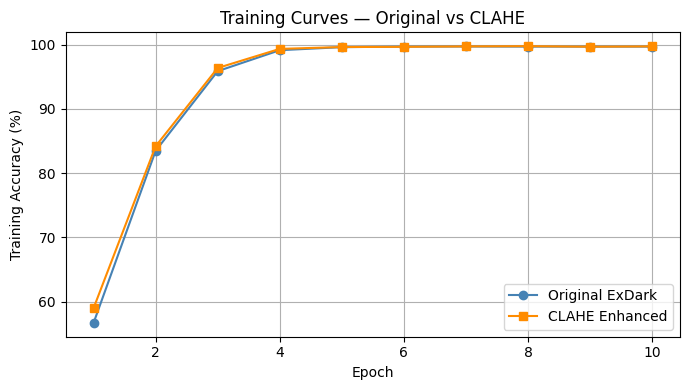

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), [a*100 for a in baseline_train_accs],
         marker='o', color='steelblue', label='Original ExDark')
plt.plot(range(1, EPOCHS+1), [a*100 for a in clahe_train_accs],
         marker='s', color='darkorange', label='CLAHE Enhanced')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Curves — Original vs CLAHE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_curves_comparison.png", dpi=150)
plt.show()

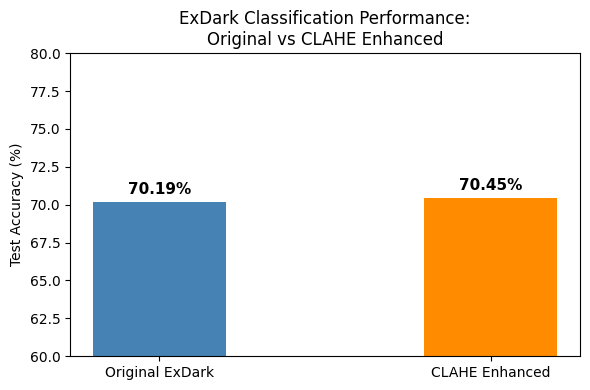


Baseline Accuracy : 70.19%
CLAHE Accuracy    : 70.45%
Improvement       : +0.27%


In [17]:
methods = ["Original ExDark", "CLAHE Enhanced"]
accs    = [baseline_acc * 100, clahe_acc * 100]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, accs, color=['steelblue', 'darkorange'], width=0.4)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(60, 80)
plt.ylabel("Test Accuracy (%)")
plt.title("ExDark Classification Performance:\nOriginal vs CLAHE Enhanced")
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

print(f"\nBaseline Accuracy : {accs[0]:.2f}%")
print(f"CLAHE Accuracy    : {accs[1]:.2f}%")
print(f"Improvement       : +{accs[1]-accs[0]:.2f}%")

In [18]:
%pip install pandas

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd

results = {
    'Method':        ['Original ExDark', 'CLAHE Enhanced'],
    'Test Accuracy': [f'{baseline_acc*100:.2f}%', f'{clahe_acc*100:.2f}%'],
    'Improvement':   ['-', f'+{(clahe_acc - baseline_acc)*100:.2f}%']
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

         Method Test Accuracy Improvement
Original ExDark        70.19%           -
 CLAHE Enhanced        70.45%      +0.27%


In [20]:
# Find examples where Original fails but CLAHE succeeds
model_baseline.eval()
model_clahe.eval()

# Use no-shuffle test loaders with idx tracking
orig_dataset  = datasets.ImageFolder("ExDark_split/test",  transform=transform)
clahe_dataset = datasets.ImageFolder("ExDark_CLAHE/test",  transform=transform)

orig_loader_seq  = DataLoader(orig_dataset,  batch_size=1, shuffle=False)
clahe_loader_seq = DataLoader(clahe_dataset, batch_size=1, shuffle=False)

success_cases = []  # (orig_path, clahe_path, true_label, orig_pred, clahe_pred)

img_paths = [s[0] for s in orig_dataset.samples]

with torch.no_grad():
    for i, ((orig_img, label), (clahe_img, _)) in enumerate(
        zip(orig_loader_seq, clahe_loader_seq)
    ):
        orig_img  = orig_img.to(device)
        clahe_img = clahe_img.to(device)

        orig_pred  = model_baseline(orig_img).argmax(1).item()
        clahe_pred = model_clahe(clahe_img).argmax(1).item()
        true_lbl   = label.item()

        # Case: Original fails, CLAHE succeeds
        if orig_pred != true_lbl and clahe_pred == true_lbl:
            orig_path  = img_paths[i]
            clahe_path = orig_path.replace("ExDark_split", "ExDark_CLAHE")
            success_cases.append((
                orig_path, clahe_path,
                class_names[true_lbl],
                class_names[orig_pred],
                class_names[clahe_pred]
            ))
        if len(success_cases) >= 4:
            break

print(f"Found {len(success_cases)} cases where CLAHE helps")

Found 4 cases where CLAHE helps


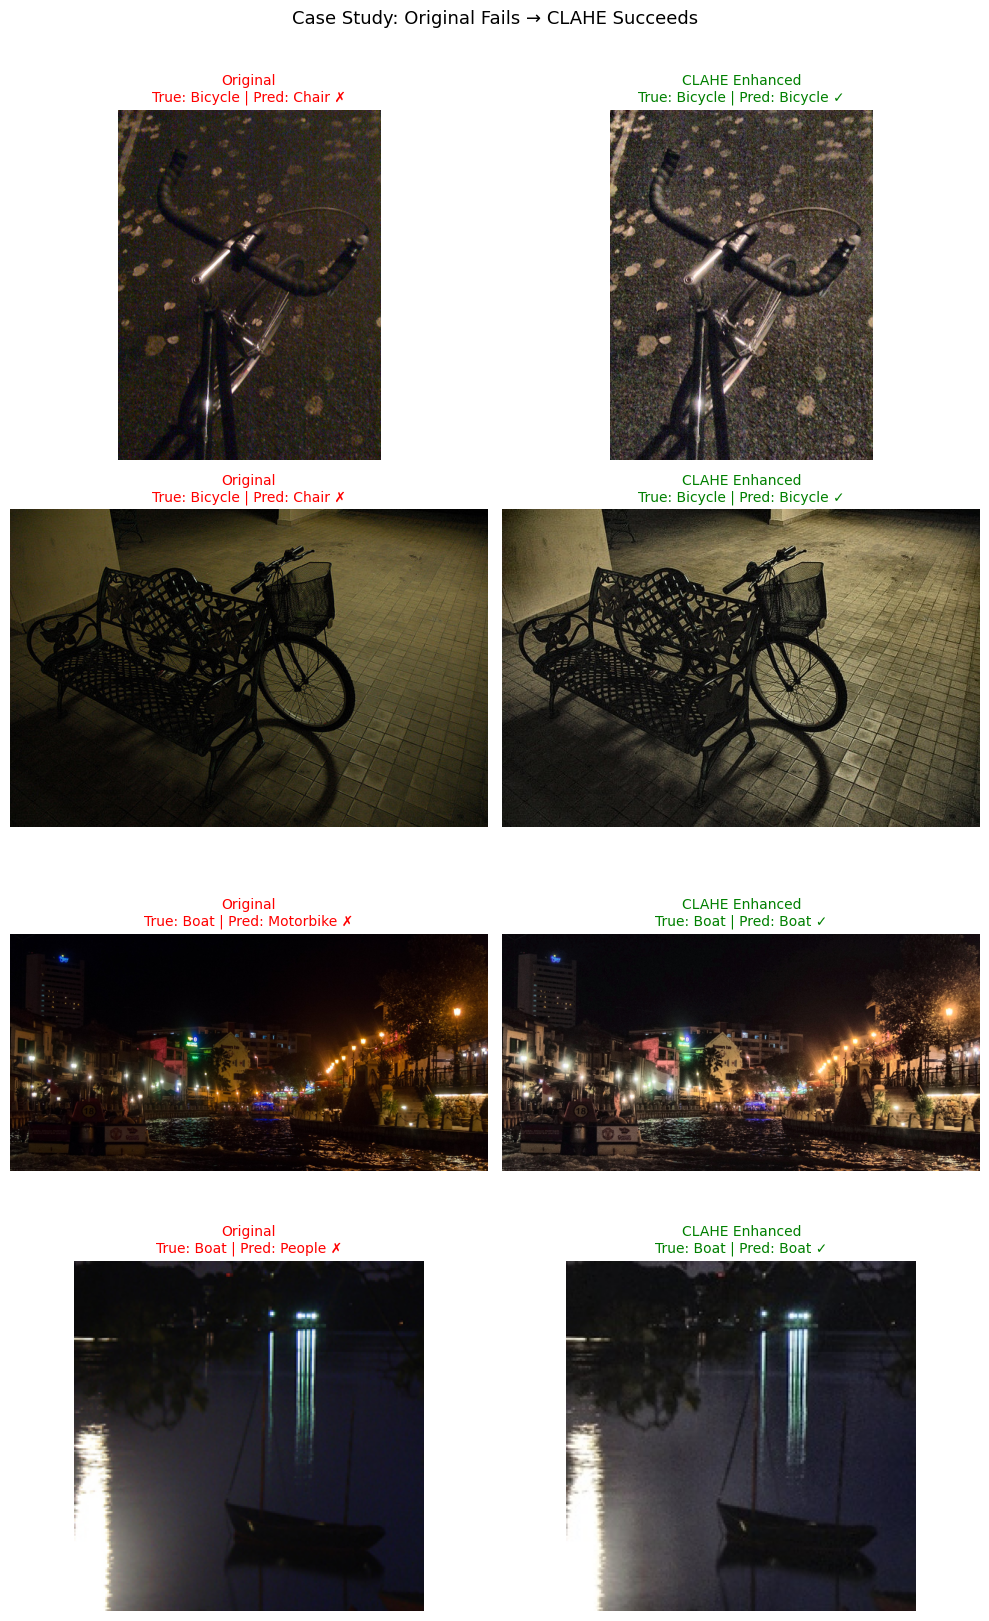

In [21]:
fig, axes = plt.subplots(len(success_cases), 2, figsize=(10, 4 * len(success_cases)))

for i, (orig_path, clahe_path, true_lbl, orig_pred, clahe_pred) in enumerate(success_cases):

    orig_img  = cv2.cvtColor(cv2.imread(orig_path),  cv2.COLOR_BGR2RGB)
    clahe_img = cv2.cvtColor(cv2.imread(clahe_path), cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(orig_img)
    axes[i][0].set_title(
        f"Original\nTrue: {true_lbl} | Pred: {orig_pred} ✗",
        color='red', fontsize=10
    )
    axes[i][0].axis('off')

    axes[i][1].imshow(clahe_img)
    axes[i][1].set_title(
        f"CLAHE Enhanced\nTrue: {true_lbl} | Pred: {clahe_pred} ✓",
        color='green', fontsize=10
    )
    axes[i][1].axis('off')

plt.suptitle("Case Study: Original Fails → CLAHE Succeeds", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("case_study_clahe_helps.png", dpi=150, bbox_inches='tight')
plt.show()

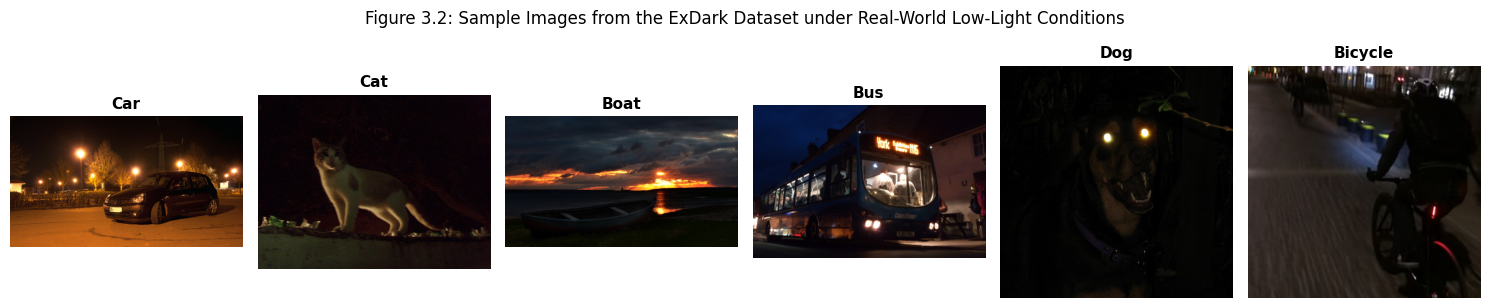

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import os, random

exdark_dir = "ExDark_split/test"
selected_classes = ["Car", "Cat", "Boat", "Bus", "Dog", "Bicycle"]

fig, axes = plt.subplots(1, len(selected_classes), figsize=(15, 3))

for i, cls in enumerate(selected_classes):
    cls_dir = os.path.join(exdark_dir, cls)
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(cls_dir, random.choice(files))
    img = Image.open(img_path).convert("RGB")
    
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Figure 3.2: Sample Images from the ExDark Dataset under Real-World Low-Light Conditions",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figure3_2_exdark_samples.png", dpi=150, bbox_inches='tight')
plt.show()